# 04.2 — Deep Agent Value Frontier (Rigorous Comparison)

## Goal

Part 2 of the evaluation milestone (continues from **04.1**).

In 04.1 we built the evaluation layers (deterministic checks, a built-in
Foundry evaluator, and a custom research rubric) and ran a single
baseline-vs-Deep-Agent comparison to build economic intuition.

Here we make that comparison rigorous:

- run baseline model+search vs. the Deep Agent across simple / medium / complex tasks
- judge answers blind and pairwise
- repeat runs to measure win rate, not a single outcome
- compute token and latency multipliers
- plot the Deep Agent **value frontier** and interpret the quadrants

---

## Setup

The cells below re-create the model, tools, research agent, evaluation
cases, and helper functions defined in 04.1 so this notebook can run
independently. Run this setup section first; the analysis cells that
follow reuse these objects.


In [ ]:
import os

from dotenv import load_dotenv

load_dotenv()

PROJECT_ENDPOINT = os.environ["AZURE_AI_PROJECT_ENDPOINT"]
MODEL_DEPLOYMENT = os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"]

# print("Project:", PROJECT_ENDPOINT)
# print("Model:", MODEL_DEPLOYMENT)

In [ ]:
from azure.identity import DefaultAzureCredential
from langchain_azure_ai.chat_models import AzureAIOpenAIApiChatModel

credential = DefaultAzureCredential()

model = AzureAIOpenAIApiChatModel(
    project_endpoint=PROJECT_ENDPOINT,
    credential=credential,
    model=MODEL_DEPLOYMENT,
)

In [ ]:
from langchain_azure_ai.tools.builtin import WebSearchTool

web_search = WebSearchTool()

In [ ]:
from deepagents import create_deep_agent

research_instructions = """
You are an expert research assistant.

Your job is to research questions thoroughly and produce concise,
evidence-grounded answers.

## Research behavior

- Use web search whenever current or externally verifiable information is needed.
- Prefer authoritative and primary sources when possible.
- Search more than once when the first search does not fully answer the question.
- Distinguish established facts from interpretation.
- Include source citations in your final answer when web research was used.

You also have the standard Deep Agents capabilities for planning,
filesystem-based context management, and subagent delegation.
"""

research_agent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt=research_instructions,
)

In [ ]:
eval_cases = [
    {
        "id": "freshness",
        "query": """
What are the most consequential recent updates to Microsoft Foundry
for an enterprise AI architect?

Use current Microsoft documentation and give me three important changes.
""",
        "expects_search": True,
        "expects_file": False,
    },
    {
        "id": "structured_research",
        "query": """
Research the current Microsoft guidance for building and operating
custom agents in Foundry.

Write important findings to /research_notes.md,
read the notes back,
then provide a concise architecture summary with citations.
""",
        "expects_search": True,
        "expects_file": True,
    },
    {
        "id": "simple_concept",
        "query": """
Explain in simple terms what a Foundry Hosted Agent is
and when I would use one instead of a prompt agent.
""",
        "expects_search": False,
        "expects_file": False,
    },
]

len(eval_cases)

In [ ]:
import time


def run_eval_case(agent, case):
    start = time.perf_counter()

    result = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": case["query"],
                }
            ]
        }
    )

    elapsed = time.perf_counter() - start

    return {
        "case": case,
        "result": result,
        "messages": result["messages"],
        "final_message": result["messages"][-1],
        "elapsed_seconds": elapsed,
    }

In [ ]:
def extract_trajectory_features(messages):
    server_tool_calls = 0
    local_tool_calls = []
    has_write_file = False
    has_read_file = False

    for message in messages:
        tool_calls = getattr(message, "tool_calls", None) or []

        for call in tool_calls:
            name = call.get("name")
            local_tool_calls.append(name)

            if name == "write_file":
                has_write_file = True

            if name == "read_file":
                has_read_file = True

        content_blocks = getattr(message, "content_blocks", None) or []

        for block in content_blocks:
            if block.get("type") == "server_tool_call":
                server_tool_calls += 1

    return {
        "server_tool_calls": server_tool_calls,
        "local_tool_calls": local_tool_calls,
        "has_write_file": has_write_file,
        "has_read_file": has_read_file,
    }

In [ ]:
def has_citation_like_content(message):
    text = str(message.content)

    return (
        "http" in text
        or "cite" in text.lower()
        or "source" in text.lower()
    )

In [ ]:
def deterministic_evaluation(run):
    case = run["case"]
    trajectory = extract_trajectory_features(run["messages"])

    checks = {}

    checks["completed"] = bool(run["final_message"].content)

    if case["expects_search"]:
        checks["searched_when_expected"] = (
            trajectory["server_tool_calls"] > 0
        )

    if case["expects_file"]:
        checks["wrote_file"] = trajectory["has_write_file"]
        checks["read_file"] = trajectory["has_read_file"]

    if case["expects_search"]:
        checks["citations_present"] = has_citation_like_content(
            run["final_message"]
        )

    checks["elapsed_seconds"] = run["elapsed_seconds"]
    checks["server_tool_calls"] = trajectory["server_tool_calls"]

    return checks

In [ ]:
def aggregate_usage(messages):
    input_tokens = 0
    output_tokens = 0
    total_tokens = 0

    for message in messages:
        usage = getattr(message, "usage_metadata", None)

        if not usage:
            continue

        input_tokens += usage.get("input_tokens", 0)
        output_tokens += usage.get("output_tokens", 0)
        total_tokens += usage.get("total_tokens", 0)

    return {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
    }

## Baseline model+search vs Deep Agent experiment on 3 eval cases

In [76]:
runs = []

for case in eval_cases:
    print(f"\nRunning: {case['id']}")

    run = run_eval_case(research_agent, case)
    run["deterministic"] = deterministic_evaluation(run)
    run["trajectory"] = extract_trajectory_features(run["messages"])

    runs.append(run)

print("\nDone.")


Running: freshness

Running: structured_research

Running: simple_concept

Done.


In [ ]:
for run in runs:
    print("\n" + "=" * 80)
    print(run["case"]["id"])
    print("=" * 80)

    print("\nDETERMINISTIC:")
    print(run["deterministic"])

    print("\nTRAJECTORY:")
    print(run["trajectory"])

    print("\nFINAL ANSWER:")
    print(run["final_message"].content)

In [79]:
for run in runs:
    run["usage"] = aggregate_usage(run["messages"])
    print(f"\n{run['case']['id']} usage:", run["usage"])


freshness usage: {'input_tokens': 16682, 'output_tokens': 985, 'total_tokens': 17667}

structured_research usage: {'input_tokens': 38703, 'output_tokens': 2237, 'total_tokens': 40940}

simple_concept usage: {'input_tokens': 12511, 'output_tokens': 640, 'total_tokens': 13151}


In [81]:
baseline_model = model.bind_tools([web_search])

def run_baseline(query):
    start = time.perf_counter()

    response = baseline_model.invoke(query)

    elapsed = time.perf_counter() - start

    return {
        "response": response,
        "elapsed_seconds": elapsed,
        "usage": getattr(response, "usage_metadata", None) or {},
    }

### Simple task

In [82]:
simple_query = """
Explain what a Microsoft Foundry Hosted Agent is and when I would
choose it instead of a prompt agent.

Use current Microsoft documentation.
Keep the answer concise.
"""

simple_baseline = run_baseline(simple_query)

In [83]:
simple_deep = run_eval_case(
    research_agent,
    {
        "id": "simple_comparison",
        "query": simple_query,
        "expects_search": True,
        "expects_file": False,
    },
)

simple_deep["usage"] = aggregate_usage(simple_deep["messages"])
simple_deep["trajectory"] = extract_trajectory_features(simple_deep["messages"])

In [84]:
print("BASELINE")
print(simple_baseline["response"].content)

print("\n" + "=" * 80)

print("DEEP AGENT")
print(simple_deep["final_message"].content)

BASELINE
[{'id': 'ws_065274a81b4642a4006a9e69c9cfa88193b6062c8f8ddcb812', 'action': {'type': 'search', 'queries': ['Microsoft Foundry hosted agent definition', 'prompt agent Microsoft Foundry documentation', 'Azure AI Foundry hosted agent vs prompt agent', 'Microsoft Foundry Agents hosted agent documentation'], 'query': 'Microsoft Foundry hosted agent definition'}, 'status': 'completed', 'type': 'web_search_call', 'response_id': 'resp_065274a81b4642a4006a9e69c8bd048193ae69d9aee8499d90'}, {'type': 'text', 'text': 'A **Microsoft Foundry Hosted Agent** is an agent you **package and deploy as your own code** (typically as a **containerized application**) to **Microsoft Foundry Agent Service**, where Microsoft provides the **managed hosting/runtime**: scaling, security/identity integration, session state persistence, lifecycle management, and observability—so you focus on the agent logic and orchestration. ([learn.microsoft.com](https://learn.microsoft.com/en-us/azure/foundry/agents/concept

In [85]:
print("BASELINE")
print("Seconds:", round(simple_baseline["elapsed_seconds"], 1))
print("Usage:", simple_baseline["usage"])

print("\nDEEP AGENT")
print("Seconds:", round(simple_deep["elapsed_seconds"], 1))
print("Usage:", simple_deep["usage"])
print("Trajectory:", simple_deep["trajectory"])

BASELINE
Seconds: 12.4
Usage: {'input_tokens': 8526, 'output_tokens': 527, 'total_tokens': 9053, 'input_token_details': {'cache_creation': 0, 'cache_read': 4224}, 'output_token_details': {'reasoning': 80}}

DEEP AGENT
Seconds: 9.5
Usage: {'input_tokens': 10658, 'output_tokens': 456, 'total_tokens': 11114}
Trajectory: {'server_tool_calls': 1, 'local_tool_calls': [], 'has_write_file': False, 'has_read_file': False}


### Medium-complexity Task

In [86]:
medium_query = """
Research three viable approaches for productionizing a custom
enterprise research agent on Microsoft Foundry.

Compare them across:

- orchestration control
- deployment model
- identity
- tooling
- observability
- evaluation
- operational complexity

Use current Microsoft documentation.

Recommend when each approach is appropriate.
"""

medium_baseline = run_baseline(medium_query)

In [87]:
medium_deep = run_eval_case(
    research_agent,
    {
        "id": "medium_comparison",
        "query": medium_query,
        "expects_search": True,
        "expects_file": False,
    },
)

medium_deep["usage"] = aggregate_usage(medium_deep["messages"])
medium_deep["trajectory"] = extract_trajectory_features(medium_deep["messages"])

### Complex task - Suited for Deep Agents

In [88]:
complex_query = """
Investigate how to productionize an open-source Deep Agents / LangGraph
research agent on Microsoft Foundry.

Research and reason through:

1. model integration
2. web search and tools
3. Hosted Agent deployment
4. managed identity and RBAC
5. workspace and state
6. private networking
7. observability
8. evaluation
9. versioning and operations

For each area:

- find current Microsoft guidance
- identify important constraints or limitations
- connect it to the overall architecture

Then synthesize:

- a recommended production architecture
- major design trade-offs
- top implementation risks
- an ordered implementation plan

Use current Microsoft documentation.
"""

complex_baseline = run_baseline(complex_query)

In [89]:
complex_deep = run_eval_case(
    research_agent,
    {
        "id": "complex_comparison",
        "query": complex_query,
        "expects_search": True,
        "expects_file": False,
    },
)

complex_deep["usage"] = aggregate_usage(complex_deep["messages"])
complex_deep["trajectory"] = extract_trajectory_features(complex_deep["messages"])

### Blind pairwise judge

In [90]:
import json


def compare_answers(query, answer_a, answer_b):
    prompt = f"""
You are evaluating two answers to the same enterprise technical research task.

TASK:
{query}

ANSWER A:
{answer_a}

ANSWER B:
{answer_b}

Evaluate each independently from 1 to 5 on:

1. Task completion
2. Research completeness
3. Evidence quality
4. Grounding
5. Synthesis
6. Decision usefulness

Then provide:

- score for A on each dimension
- score for B on each dimension
- overall score for A from 1 to 5
- overall score for B from 1 to 5
- winner: A, B, or tie
- difference: negligible, small, moderate, or large
- concise explanation

Do not infer or discuss how either answer was produced.

Return valid JSON only.
"""

    result = model.invoke(prompt)

    text = result.content

    if isinstance(text, list):
        text = "".join(
            block.get("text", "")
            for block in text
            if isinstance(block, dict)
        )

    return text

In [91]:
simple_judgment = compare_answers(
    simple_query,
    str(simple_baseline["response"].content),
    str(simple_deep["final_message"].content),
)

print(simple_judgment)

{
  "scores": {
    "A": {
      "task_completion": 4,
      "research_completeness": 4,
      "evidence_quality": 4,
      "grounding": 4,
      "synthesis": 4,
      "decision_usefulness": 4
    },
    "B": {
      "task_completion": 5,
      "research_completeness": 4,
      "evidence_quality": 4,
      "grounding": 4,
      "synthesis": 5,
      "decision_usefulness": 5
    }
  },
  "overall": {
    "A": 4,
    "B": 5
  },
  "winner": "B",
  "difference": "small",
  "explanation": "Both answers correctly distinguish Hosted Agents (code/container deployed to Foundry Agent Service with managed operations like scaling, security, and session persistence) from prompt agents (declarative model+instructions+tools). B is more directly decision-oriented and concise, with clearer “choose hosted when…” bullets and fewer distracting artifacts, making it slightly more useful for an enterprise reader. A is solid but includes more clutter and slightly weaker focus/clarity in the selection guidanc

In [92]:
medium_judgment = compare_answers(
    medium_query,
    str(medium_baseline["response"].content),
    str(medium_deep["final_message"].content),
)

print(medium_judgment)

{
  "scores": {
    "A": {
      "task_completion": 4,
      "research_completeness": 4,
      "evidence_quality": 4,
      "grounding": 4,
      "synthesis": 4,
      "decision_usefulness": 4
    },
    "B": {
      "task_completion": 5,
      "research_completeness": 5,
      "evidence_quality": 4,
      "grounding": 4,
      "synthesis": 5,
      "decision_usefulness": 5
    }
  },
  "overall": {
    "A": 4,
    "B": 5
  },
  "winner": "B",
  "difference": "small",
  "explanation": "Answer A delivers three plausible approaches and compares them across the requested dimensions with relevant Microsoft Foundry citations, but one approach (“Prompt Agent”) is less crisply tied to a single, clearly documented Foundry productionization path and the identity/deployment specifics are occasionally generalized. Answer B provides three cleanly delineated, production-oriented approaches that map tightly to documented Foundry capabilities (hosted agents, workflows, external agent registration) an

In [93]:
complex_judgment = compare_answers(
    complex_query,
    str(complex_baseline["response"].content),
    str(complex_deep["final_message"].content),
)

print(complex_judgment)

{
  "scores": {
    "A": {
      "task_completion": 4,
      "research_completeness": 3,
      "evidence_quality": 3,
      "grounding": 3,
      "synthesis": 4,
      "decision_usefulness": 4
    },
    "B": {
      "task_completion": 5,
      "research_completeness": 4,
      "evidence_quality": 4,
      "grounding": 4,
      "synthesis": 4,
      "decision_usefulness": 5
    }
  },
  "overall": {
    "A": 4,
    "B": 5
  },
  "winner": "B",
  "difference": "moderate",
  "explanation": "Answer B more directly covers all nine requested areas with clearer ties to current Microsoft guidance (notably limits/quotas/regions, networking options + deep dive, RBAC-specific docs, deploy/manage hosted agent docs, and agent evaluation docs). It provides more actionable production constraints (service limits, session retention, VNet “one-way door”, rollout mechanics) and a more decision-ready implementation plan. Answer A has strong synthesis and good citations, but is weaker on explicit platform

### Calculate the economic multiplier

In [94]:
def total_tokens(usage):
    if not usage:
        return 0

    return usage.get(
        "total_tokens",
        usage.get("input_tokens", 0) + usage.get("output_tokens", 0),
    )

In [95]:
def economics_summary(baseline, deep):
    baseline_tokens = total_tokens(baseline["usage"])
    deep_tokens = total_tokens(deep["usage"])

    token_multiplier = (
        deep_tokens / baseline_tokens
        if baseline_tokens
        else None
    )

    latency_multiplier = (
        deep["elapsed_seconds"] / baseline["elapsed_seconds"]
        if baseline["elapsed_seconds"]
        else None
    )

    return {
        "baseline_tokens": baseline_tokens,
        "deep_tokens": deep_tokens,
        "token_multiplier": token_multiplier,
        "baseline_seconds": baseline["elapsed_seconds"],
        "deep_seconds": deep["elapsed_seconds"],
        "latency_multiplier": latency_multiplier,
    }

In [96]:
simple_economics = economics_summary(
    simple_baseline,
    simple_deep,
)

medium_economics = economics_summary(
    medium_baseline,
    medium_deep,
)

complex_economics = economics_summary(
    complex_baseline,
    complex_deep,
)

In [97]:
print("SIMPLE")
print(simple_economics)

print("\nMEDIUM")
print(medium_economics)

print("\nCOMPLEX")
print(complex_economics)

SIMPLE
{'baseline_tokens': 9053, 'deep_tokens': 11114, 'token_multiplier': 1.2276593394454878, 'baseline_seconds': 12.358190399943851, 'deep_seconds': 9.521966099971905, 'latency_multiplier': 0.7704984137495703}

MEDIUM
{'baseline_tokens': 31959, 'deep_tokens': 28696, 'token_multiplier': 0.8979004349322569, 'baseline_seconds': 49.17653729999438, 'deep_seconds': 49.02852809999604, 'latency_multiplier': 0.99699024762367}

COMPLEX
{'baseline_tokens': 25704, 'deep_tokens': 23468, 'token_multiplier': 0.913009648303766, 'baseline_seconds': 70.29932019999251, 'deep_seconds': 88.91210079996381, 'latency_multiplier': 1.264764730967815}


### Put everything (economics) in one table

In [98]:
import pandas as pd

comparison_df = pd.DataFrame(
    [
        {
            "task": "simple",
            "baseline_tokens": simple_economics["baseline_tokens"],
            "deep_tokens": simple_economics["deep_tokens"],
            "token_multiplier": simple_economics["token_multiplier"],
            "baseline_sec": simple_economics["baseline_seconds"],
            "deep_sec": simple_economics["deep_seconds"],
            "latency_multiplier": simple_economics["latency_multiplier"],
            "deep_searches": simple_deep["trajectory"]["server_tool_calls"],
        },
        {
            "task": "medium",
            "baseline_tokens": medium_economics["baseline_tokens"],
            "deep_tokens": medium_economics["deep_tokens"],
            "token_multiplier": medium_economics["token_multiplier"],
            "baseline_sec": medium_economics["baseline_seconds"],
            "deep_sec": medium_economics["deep_seconds"],
            "latency_multiplier": medium_economics["latency_multiplier"],
            "deep_searches": medium_deep["trajectory"]["server_tool_calls"],
        },
        {
            "task": "complex",
            "baseline_tokens": complex_economics["baseline_tokens"],
            "deep_tokens": complex_economics["deep_tokens"],
            "token_multiplier": complex_economics["token_multiplier"],
            "baseline_sec": complex_economics["baseline_seconds"],
            "deep_sec": complex_economics["deep_seconds"],
            "latency_multiplier": complex_economics["latency_multiplier"],
            "deep_searches": complex_deep["trajectory"]["server_tool_calls"],
        },
    ]
)

comparison_df

,task,baseline_tokens,deep_tokens,token_multiplier,baseline_sec,deep_sec,latency_multiplier,deep_searches
0,simple,9053,11114,1.227659,12.358190,9.521966,0.770498,1
1,medium,31959,28696,0.897900,49.176537,49.028528,0.996990,3
2,complex,25704,23468,0.913010,70.299320,88.912101,1.264765,3


In [101]:
simple_judgment_json = json.loads(simple_judgment)
simple_judgment_json



{'scores': {'A': {'task_completion': 4,
   'research_completeness': 4,
   'evidence_quality': 4,
   'grounding': 4,
   'synthesis': 4,
   'decision_usefulness': 4},
  'B': {'task_completion': 5,
   'research_completeness': 4,
   'evidence_quality': 4,
   'grounding': 4,
   'synthesis': 5,
   'decision_usefulness': 5}},
 'overall': {'A': 4, 'B': 5},
 'winner': 'B',
 'difference': 'small',
 'explanation': 'Both answers correctly distinguish Hosted Agents (code/container deployed to Foundry Agent Service with managed operations like scaling, security, and session persistence) from prompt agents (declarative model+instructions+tools). B is more directly decision-oriented and concise, with clearer “choose hosted when…” bullets and fewer distracting artifacts, making it slightly more useful for an enterprise reader. A is solid but includes more clutter and slightly weaker focus/clarity in the selection guidance.'}

In [108]:
comparison_df["baseline_quality"] = [
    # simple
    json.loads(simple_judgment)["overall"]["A"],
    # medium
    json.loads(medium_judgment)["overall"]["A"],
    # complex
    json.loads(complex_judgment)["overall"]["A"],
]

comparison_df["deep_quality"] = [
    json.loads(simple_judgment)["overall"]["B"],
    json.loads(medium_judgment)["overall"]["B"],
    json.loads(complex_judgment)["overall"]["B"],
]

comparison_df

,task,baseline_tokens,deep_tokens,token_multiplier,baseline_sec,deep_sec,latency_multiplier,deep_searches,baseline_quality,deep_quality
0,simple,9053,11114,1.227659,12.358190,9.521966,0.770498,1,4,5
1,medium,31959,28696,0.897900,49.176537,49.028528,0.996990,3,4,5
2,complex,25704,23468,0.913010,70.299320,88.912101,1.264765,3,4,5


In [109]:
comparison_df["quality_gain"] = (
    comparison_df["deep_quality"]
    - comparison_df["baseline_quality"]
)

comparison_df["quality_gain_per_token_multiple"] = (
    comparison_df["quality_gain"]
    / comparison_df["token_multiplier"]
)

comparison_df

,task,baseline_tokens,deep_tokens,token_multiplier,baseline_sec,deep_sec,latency_multiplier,deep_searches,baseline_quality,deep_quality,quality_gain,quality_gain_per_token_multiple
0,simple,9053,11114,1.227659,12.358190,9.521966,0.770498,1,4,5,1,0.814558
1,medium,31959,28696,0.897900,49.176537,49.028528,0.996990,3,4,5,1,1.113709
2,complex,25704,23468,0.913010,70.299320,88.912101,1.264765,3,4,5,1,1.095279


### Small Repeatable Experiment

In [111]:
comparison_tasks = [
    {
        "task": "simple",
        "query": simple_query,
    },
    {
        "task": "medium",
        "query": medium_query,
    },
    {
        "task": "complex",
        "query": complex_query,
    },
]

comparison_tasks

[{'task': 'simple',
  'query': '\nExplain what a Microsoft Foundry Hosted Agent is and when I would\nchoose it instead of a prompt agent.\n\nUse current Microsoft documentation.\nKeep the answer concise.\n'},
 {'task': 'medium',
  'query': '\nResearch three viable approaches for productionizing a custom\nenterprise research agent on Microsoft Foundry.\n\nCompare them across:\n\n- orchestration control\n- deployment model\n- identity\n- tooling\n- observability\n- evaluation\n- operational complexity\n\nUse current Microsoft documentation.\n\nRecommend when each approach is appropriate.\n'},
 {'task': 'complex',
  'query': '\nInvestigate how to productionize an open-source Deep Agents / LangGraph\nresearch agent on Microsoft Foundry.\n\nResearch and reason through:\n\n1. model integration\n2. web search and tools\n3. Hosted Agent deployment\n4. managed identity and RBAC\n5. workspace and state\n6. private networking\n7. observability\n8. evaluation\n9. versioning and operations\n\nFor e

In [112]:
def run_deep_agent(query):
    start = time.perf_counter()

    result = research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": query,
                }
            ]
        }
    )

    elapsed = time.perf_counter() - start

    messages = result["messages"]

    return {
        "answer": str(messages[-1].content),
        "usage": aggregate_usage(messages),
        "elapsed_seconds": elapsed,
        "trajectory": extract_trajectory_features(messages),
        "raw_result": result,
    }

In [113]:
def run_baseline_agent(query):
    start = time.perf_counter()

    response = baseline_model.invoke(query)

    elapsed = time.perf_counter() - start

    return {
        "answer": str(response.content),
        "usage": getattr(response, "usage_metadata", None) or {},
        "elapsed_seconds": elapsed,
        "raw_result": response,
    }

In [115]:
# Make the blind judge truly blind

import random
import json

random.seed(42)

def blind_compare(query, baseline_answer, deep_answer):
    deep_is_a = random.choice([True, False])

    if deep_is_a:
        answer_a = deep_answer
        answer_b = baseline_answer
    else:
        answer_a = baseline_answer
        answer_b = deep_answer

    prompt = f"""
You are evaluating two answers to the same enterprise technical research task.

TASK:
{query}

ANSWER A:
{answer_a}

ANSWER B:
{answer_b}

Evaluate each independently from 1 to 5 on:

1. Task completion
2. Research completeness
3. Evidence quality
4. Grounding
5. Synthesis
6. Decision usefulness

Return valid JSON in exactly this shape:

{{
  "answer_a": {{
    "overall_score": 0,
    "task_completion": 0,
    "research_completeness": 0,
    "evidence_quality": 0,
    "grounding": 0,
    "synthesis": 0,
    "decision_usefulness": 0
  }},
  "answer_b": {{
    "overall_score": 0,
    "task_completion": 0,
    "research_completeness": 0,
    "evidence_quality": 0,
    "grounding": 0,
    "synthesis": 0,
    "decision_usefulness": 0
  }},
  "winner": "A",
  "difference": "small",
  "reason": "..."
}}

Do not discuss or infer how either answer was generated.
"""

    response = model.invoke(prompt)

    text = response.content

    if isinstance(text, list):
        text = "".join(
            block.get("text", "")
            for block in text
            if isinstance(block, dict)
        )

    judgment = json.loads(text)

    if deep_is_a:
        deep_score = judgment["answer_a"]["overall_score"]
        baseline_score = judgment["answer_b"]["overall_score"]
        winner = (
            "deep"
            if judgment["winner"] == "A"
            else "baseline"
            if judgment["winner"] == "B"
            else "tie"
        )
    else:
        deep_score = judgment["answer_b"]["overall_score"]
        baseline_score = judgment["answer_a"]["overall_score"]
        winner = (
            "baseline"
            if judgment["winner"] == "A"
            else "deep"
            if judgment["winner"] == "B"
            else "tie"
        )

    return {
        "deep_score": deep_score,
        "baseline_score": baseline_score,
        "winner": winner,
        "difference": judgment["difference"],
        "reason": judgment["reason"],
        "deep_was_answer_a": deep_is_a,
        "raw_judgment": judgment,
    }

> **Heads up — cost and runtime.**
> The loop below runs `NUM_REPETITIONS` (3) repetitions across 3 task levels,
> and each repetition triggers a baseline call, a full Deep Agent run, and a
> judge call. The complex task performs long-running multi-search research, so
> a single full pass can take several minutes and consume a large number of
> tokens. Lower `NUM_REPETITIONS` or drop the `complex` task while iterating.

In [116]:
NUM_REPETITIONS = 3

experiment_results = []

for task in comparison_tasks:
    print("\n" + "=" * 80)
    print("TASK:", task["task"])
    print("=" * 80)

    for repetition in range(1, NUM_REPETITIONS + 1):
        print(f"\nRun {repetition}/{NUM_REPETITIONS}")

        print("  Running baseline...")
        baseline = run_baseline_agent(task["query"])

        print("  Running Deep Agent...")
        deep = run_deep_agent(task["query"])

        print("  Judging...")
        judgment = blind_compare(
            task["query"],
            baseline["answer"],
            deep["answer"],
        )

        experiment_results.append(
            {
                "task": task["task"],
                "repetition": repetition,

                "baseline_tokens": total_tokens(
                    baseline["usage"]
                ),
                "deep_tokens": total_tokens(
                    deep["usage"]
                ),

                "baseline_seconds": baseline[
                    "elapsed_seconds"
                ],
                "deep_seconds": deep[
                    "elapsed_seconds"
                ],

                "baseline_quality": judgment[
                    "baseline_score"
                ],
                "deep_quality": judgment[
                    "deep_score"
                ],

                "winner": judgment["winner"],
                "difference": judgment["difference"],
                "reason": judgment["reason"],

                "deep_searches": deep[
                    "trajectory"
                ]["server_tool_calls"],

                "deep_local_tools": deep[
                    "trajectory"
                ]["local_tool_calls"],
            }
        )


TASK: simple

Run 1/3
  Running baseline...
  Running Deep Agent...
  Judging...

Run 2/3
  Running baseline...
  Running Deep Agent...
  Judging...

Run 3/3
  Running baseline...
  Running Deep Agent...
  Judging...

TASK: medium

Run 1/3
  Running baseline...
  Running Deep Agent...
  Judging...

Run 2/3
  Running baseline...
  Running Deep Agent...
  Judging...

Run 3/3
  Running baseline...
  Running Deep Agent...
  Judging...

TASK: complex

Run 1/3
  Running baseline...
  Running Deep Agent...
  Judging...

Run 2/3
  Running baseline...
  Running Deep Agent...
  Judging...

Run 3/3
  Running baseline...
  Running Deep Agent...
  Judging...


In [117]:
experiment_df = pd.DataFrame(experiment_results)

experiment_df

,task,repetition,baseline_tokens,deep_tokens,baseline_seconds,deep_seconds,baseline_quality,deep_quality,winner,difference,reason,deep_searches,deep_local_tools
0,simple,1,11201,14741,14.711164,12.351537,5,4,baseline,small,Both answers correctly define Foundry Hosted A...,2,[]
1,simple,2,11121,11121,13.251002,19.421358,5,4,baseline,small,Both answers correctly distinguish hosted agen...,1,[]
2,simple,3,9068,11088,20.184338,18.095682,5,4,baseline,small,Both answers correctly define hosted agents vs...,1,[]
3,medium,1,19363,25443,50.211876,51.730283,4,4,deep,small,Both answers provide three viable approaches a...,2,[]
4,medium,2,15818,27968,47.811275,48.733139,4,4,deep,small,Answer A cleanly stays within Microsoft Foundr...,3,[]
5,medium,3,15296,22655,43.323610,54.829461,3,4,deep,medium,"Answer B provides three clearly distinct, Foun...",3,[]
6,complex,1,21571,23437,93.004099,76.158645,4,4,deep,small,Both answers cover all required areas and prov...,3,[]
7,complex,2,21955,28293,82.213424,105.406054,4,4,deep,small,Both answers cover all nine required areas and...,4,[]
8,complex,3,21471,22871,84.933625,74.442394,5,4,baseline,small,Both answers cover all nine areas with Microso...,3,[]


In [122]:
experiment_df["quality_gain"] = (
    experiment_df["deep_quality"]
    - experiment_df["baseline_quality"]
)

experiment_df["token_multiplier"] = (
    experiment_df["deep_tokens"]
    / experiment_df["baseline_tokens"]
)

experiment_df["latency_multiplier"] = (
    experiment_df["deep_seconds"]
    / experiment_df["baseline_seconds"]
)

experiment_df

,task,repetition,baseline_tokens,deep_tokens,baseline_seconds,deep_seconds,baseline_quality,deep_quality,winner,difference,reason,deep_searches,deep_local_tools,quality_gain,token_multiplier,latency_multiplier
0,simple,1,11201,14741,14.711164,12.351537,5,4,baseline,small,Both answers correctly define Foundry Hosted A...,2,[],-1,1.316043,0.839603
1,simple,2,11121,11121,13.251002,19.421358,5,4,baseline,small,Both answers correctly distinguish hosted agen...,1,[],-1,1.000000,1.465652
2,simple,3,9068,11088,20.184338,18.095682,5,4,baseline,small,Both answers correctly define hosted agents vs...,1,[],-1,1.222761,0.896521
3,medium,1,19363,25443,50.211876,51.730283,4,4,deep,small,Both answers provide three viable approaches a...,2,[],0,1.314001,1.030240
4,medium,2,15818,27968,47.811275,48.733139,4,4,deep,small,Answer A cleanly stays within Microsoft Foundr...,3,[],0,1.768112,1.019281
5,medium,3,15296,22655,43.323610,54.829461,3,4,deep,medium,"Answer B provides three clearly distinct, Foun...",3,[],1,1.481106,1.265579
6,complex,1,21571,23437,93.004099,76.158645,4,4,deep,small,Both answers cover all required areas and prov...,3,[],0,1.086505,0.818874
7,complex,2,21955,28293,82.213424,105.406054,4,4,deep,small,Both answers cover all nine required areas and...,4,[],0,1.288681,1.282103
8,complex,3,21471,22871,84.933625,74.442394,5,4,baseline,small,Both answers cover all nine areas with Microso...,3,[],-1,1.065204,0.876477


,task,deep_win_rate,baseline_win_rate,tie_rate
0,complex,0.666667,0.333333,0.0
1,medium,1.000000,0.000000,0.0
2,simple,0.000000,1.000000,0.0


In [124]:
summary_df = (
    experiment_df
    .groupby("task")
    .agg(
        baseline_quality_mean=(
            "baseline_quality", "mean"
        ),
        deep_quality_mean=(
            "deep_quality", "mean"
        ),

        quality_gain_mean=(
            "quality_gain", "mean"
        ),

        baseline_tokens_mean=(
            "baseline_tokens", "mean"
        ),
        deep_tokens_mean=(
            "deep_tokens", "mean"
        ),

        token_multiplier_mean=(
            "token_multiplier", "mean"
        ),

        baseline_seconds_mean=(
            "baseline_seconds", "mean"
        ),
        deep_seconds_mean=(
            "deep_seconds", "mean"
        ),

        latency_multiplier_mean=(
            "latency_multiplier", "mean"
        ),

        deep_searches_mean=(
            "deep_searches", "mean"
        ),
    )
    .reset_index()
)

summary_df

,task,baseline_quality_mean,deep_quality_mean,quality_gain_mean,baseline_tokens_mean,deep_tokens_mean,token_multiplier_mean,baseline_seconds_mean,deep_seconds_mean,latency_multiplier_mean,deep_searches_mean
0,complex,4.333333,4.0,-0.333333,21665.666667,24867.000000,1.146797,86.717050,85.335698,0.992485,3.333333
1,medium,3.666667,4.0,0.333333,16825.666667,25355.333333,1.521073,47.115587,51.764294,1.105034,2.666667
2,simple,5.000000,4.0,-1.000000,10463.333333,12316.666667,1.179602,16.048835,16.622859,1.067259,1.333333


In [125]:
win_rate_df = (
    experiment_df
    .assign(
        deep_win=lambda df: (
            df["winner"] == "deep"
        ).astype(int),
        baseline_win=lambda df: (
            df["winner"] == "baseline"
        ).astype(int),
        tie=lambda df: (
            df["winner"] == "tie"
        ).astype(int),
    )
    .groupby("task")
    .agg(
        deep_win_rate=("deep_win", "mean"),
        baseline_win_rate=("baseline_win", "mean"),
        tie_rate=("tie", "mean"),
    )
    .reset_index()
)

win_rate_df

,task,deep_win_rate,baseline_win_rate,tie_rate
0,complex,0.666667,0.333333,0.0
1,medium,1.000000,0.000000,0.0
2,simple,0.000000,1.000000,0.0


In [126]:
value_frontier_df = summary_df.merge(
    win_rate_df,
    on="task",
)

value_frontier_df

,task,baseline_quality_mean,deep_quality_mean,quality_gain_mean,baseline_tokens_mean,deep_tokens_mean,token_multiplier_mean,baseline_seconds_mean,deep_seconds_mean,latency_multiplier_mean,deep_searches_mean,deep_win_rate,baseline_win_rate,tie_rate
0,complex,4.333333,4.0,-0.333333,21665.666667,24867.000000,1.146797,86.717050,85.335698,0.992485,3.333333,0.666667,0.333333,0.0
1,medium,3.666667,4.0,0.333333,16825.666667,25355.333333,1.521073,47.115587,51.764294,1.105034,2.666667,1.000000,0.000000,0.0
2,simple,5.000000,4.0,-1.000000,10463.333333,12316.666667,1.179602,16.048835,16.622859,1.067259,1.333333,0.000000,1.000000,0.0


In [127]:
display_columns = [
    "task",

    "baseline_quality_mean",
    "deep_quality_mean",
    "quality_gain_mean",

    "deep_win_rate",

    "baseline_tokens_mean",
    "deep_tokens_mean",
    "token_multiplier_mean",

    "baseline_seconds_mean",
    "deep_seconds_mean",
    "latency_multiplier_mean",

    "deep_searches_mean",
]

value_frontier_df[display_columns].round(2)

,task,baseline_quality_mean,deep_quality_mean,quality_gain_mean,deep_win_rate,baseline_tokens_mean,deep_tokens_mean,token_multiplier_mean,baseline_seconds_mean,deep_seconds_mean,latency_multiplier_mean,deep_searches_mean
0,complex,4.33,4.0,-0.33,0.67,21665.67,24867.00,1.15,86.72,85.34,0.99,3.33
1,medium,3.67,4.0,0.33,1.00,16825.67,25355.33,1.52,47.12,51.76,1.11,2.67
2,simple,5.00,4.0,-1.00,0.00,10463.33,12316.67,1.18,16.05,16.62,1.07,1.33


In [128]:
for _, row in experiment_df.iterrows():
    print("\n" + "=" * 80)
    print(
        f"{row['task']} — repetition "
        f"{row['repetition']}"
    )
    print(
        f"Winner: {row['winner']} | "
        f"Difference: {row['difference']}"
    )
    print("Reason:")
    print(row["reason"])


simple — repetition 1
Winner: baseline | Difference: small
Reason:
Both answers correctly define Foundry Hosted Agents vs prompt agents and cite current Microsoft Learn pages. B is slightly clearer and more directly aligned to the decision (“bring as code” vs declarative), with cleaner bulleting and fewer extraneous artifacts, making it more concise and actionable while staying well-grounded in the cited docs.

simple — repetition 2
Winner: baseline | Difference: small
Reason:
Both answers correctly distinguish hosted agents (bring-your-own-code run on Foundry-managed hosting) from prompt agents (declarative configuration) and cite relevant Microsoft Learn pages. Answer B is more decision-useful because it enumerates concrete “choose hosted” triggers that align closely with the hosted-agents documentation (protocol flexibility, compute control, stateful/long-running/resilient work). Answer A is solid but slightly less complete and includes a cross-link to agent-framework hosting that 

In [129]:
def classify_deep_agent_value(row):
    quality_gain = row["quality_gain_mean"]
    token_mult = row["token_multiplier_mean"]
    latency_mult = row["latency_multiplier_mean"]
    win_rate = row["deep_win_rate"]

    if (
        quality_gain > 0
        and token_mult <= 1.1
        and latency_mult <= 1.2
        and win_rate >= 0.67
    ):
        return "Strong value"

    if (
        quality_gain > 0
        and win_rate >= 0.67
    ):
        return "Quality gain with resource trade-off"

    if (
        quality_gain <= 0
        and token_mult > 1
    ):
        return "Likely over-agented"

    return "Mixed / needs more evidence"

In [130]:
value_frontier_df["interpretation"] = (
    value_frontier_df.apply(
        classify_deep_agent_value,
        axis=1,
    )
)

value_frontier_df[
    [
        "task",
        "quality_gain_mean",
        "deep_win_rate",
        "token_multiplier_mean",
        "latency_multiplier_mean",
        "interpretation",
    ]
].round(2)

,task,quality_gain_mean,deep_win_rate,token_multiplier_mean,latency_multiplier_mean,interpretation
0,complex,-0.33,0.67,1.15,0.99,Likely over-agented
1,medium,0.33,1.00,1.52,1.11,Quality gain with resource trade-off
2,simple,-1.00,0.00,1.18,1.07,Likely over-agented


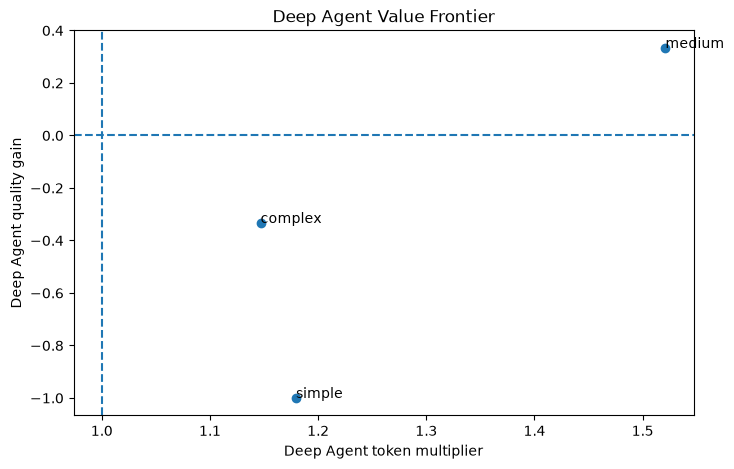

In [132]:
# Our first value-frontier visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    value_frontier_df["token_multiplier_mean"],
    value_frontier_df["quality_gain_mean"],
)

for _, row in value_frontier_df.iterrows():
    plt.annotate(
        row["task"],
        (
            row["token_multiplier_mean"],
            row["quality_gain_mean"],
        ),
    )

plt.axvline(1.0, linestyle="--")
plt.axhline(0.0, linestyle="--")

plt.xlabel("Deep Agent token multiplier")
plt.ylabel("Deep Agent quality gain")
plt.title("Deep Agent Value Frontier")

plt.show()

### Interpret the quadrants

```
                 QUALITY GAIN
                      ↑

      BEST            │        EXPENSIVE BUT BETTER
                      │
 fewer tokens         │          more tokens
 better quality       │          better quality
──────────────────────┼────────────────────────→
                      │                    TOKEN MULTIPLIER
 fewer tokens         │          more tokens
 no quality gain      │          no quality gain
                      │
   EFFICIENT BUT      │         WORST
   NO EXTRA VALUE
```

We want Deep Agents to land mostly in the upper half.

Upper-left is particularly attractive:
```
quality ↑
tokens ↓
```

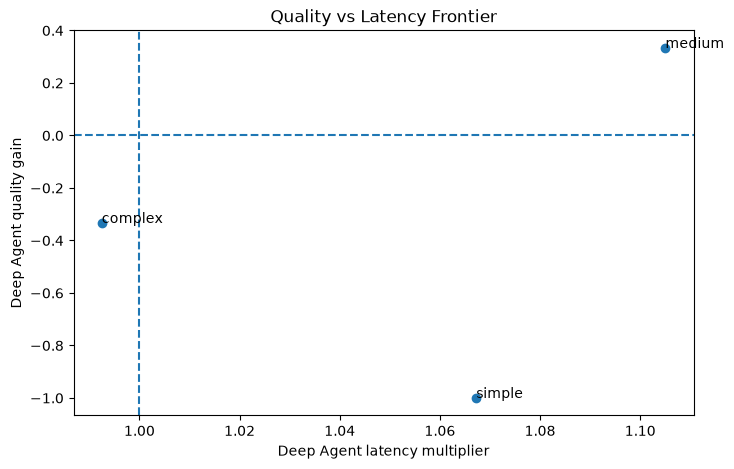

In [133]:
# Add latency as a separate view

plt.figure(figsize=(8, 5))

plt.scatter(
    value_frontier_df["latency_multiplier_mean"],
    value_frontier_df["quality_gain_mean"],
)

for _, row in value_frontier_df.iterrows():
    plt.annotate(
        row["task"],
        (
            row["latency_multiplier_mean"],
            row["quality_gain_mean"],
        ),
    )

plt.axvline(1.0, linestyle="--")
plt.axhline(0.0, linestyle="--")

plt.xlabel("Deep Agent latency multiplier")
plt.ylabel("Deep Agent quality gain")
plt.title("Quality vs Latency Frontier")

plt.show()

# Repeatability experiment

We are no longer asking:

> Did Deep Agents win once?

We are asking:

> Does Deep Agents repeatedly produce a better outcome?


For each task level we now measure:

- average baseline quality
- average Deep Agent quality
- Deep Agent win rate
- token multiplier
- latency multiplier
- search depth
- judge explanations


## The key decision

Deep Agents earns its complexity when:

```
Quality gain
+
Task-success improvement
```

is meaningfully greater than:

```
Token cost
+
Tool cost
+
Latency
+
Operational complexity
```

This is the beginning of a Deep Agent value frontier.